# Detecting Market-Stress Regimes with Multivariate Matrix Profiles
**Time-series anomaly detection on SPY (2018 to 2025) using `stumpy`**

DATA605 final project

---

## Abstract

We apply the multivariate matrix profile (Yeh et al., 2017) to the joint
dynamics of SPY log returns, realized volatility, and normalized dollar
volume between January 2018 and the present, using the **left** (causal)
variant so that detection never relies on future information. Discords
are validated against a hand-curated set of well-known stress events
(Volmageddon, the 2018 Q4 selloff, COVID-19, the 2022 rate shock, the
March 2023 SVB crisis, the August 2024 yen-carry unwind), benchmarked
against three baselines (rolling z-score, Isolation Forest, GARCH(1,1)
standardized residuals), and finally embedded into a walk-forward
risk-off overlay on a vol-targeted SPY position.

**The headline finding is mixed.** The LEFT matrix profile underperforms
point-outlier detectors on the labeled-event AUPRC metric (Isolation
Forest dominates the comparison) because the matrix profile is by
design a *novelty* detector rather than a *magnitude* detector. Its
top-ranked discords are dates where the joint $(r, \sigma, \text{vol})$
*pattern* was unprecedented (mid-2018, the FTX period, the late-Feb 2023
hawkish repricing) rather than dates where any single feature was tail.

In the trading evaluation, however, the **unweighted ensemble** (max
percentile rank across MP, IF, GARCH) used as a risk-off filter on a
vol-target overlay produces the highest Sharpe (0.71 vs 0.67 for
vol-target alone) and the smallest max-drawdown ($-16\%$ vs $-20\%$) of
any strategy considered. The matrix profile earns its keep here
specifically by adding novelty signal that magnitude-based detectors
cannot see. The MP-only filter, by contrast, *never triggers* under an
expanding-window threshold, itself an important operational finding.

## Why this is non-trivial

A naive application of `stumpy.stump` to the raw price series
"discovers" that uptrends look different from downtrends; the matrix
profile flags trend changes, not anomalies. Working on **stationary
features** is essential. The two methodological choices that matter:

1. **Inputs are stationary.** We use log returns, rolling realized
   volatility, and a z-scored dollar-volume series, never the raw price.
2. **The detector is multivariate.** Single-feature MP on returns alone
   conflates large directional moves with structural anomalies. We use
   `stumpy.mstump` and report the joint (all-dimensions) profile, which
   isolates dates where the *combination* of return, vol, volume is
   unusual.

We are also careful that every signal used for the trading overlay is
**causal**: thresholds are computed on an expanding window, and weights
are lagged one day before being applied to next-day returns.


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import stumpy
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)
from arch import arch_model

# Project-specific helpers (see stumpy_utils.py).
import stumpy_utils as stu

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)

TICKER     = "SPY"
START_DATE = "2018-01-01"
END_DATE   = "2025-04-01"
WINDOW     = 21          # ~1 trading month, the subsequence length for STUMP.
VOL_LOOKBACK    = 20
VOLUME_LOOKBACK = 60


## 2. Data acquisition

Daily OHLCV is pulled from Yahoo Finance via `stu.load_prices`, which
caches the result locally so re-runs are deterministic and offline-friendly.


In [2]:
prices = stu.load_prices(TICKER, START_DATE, END_DATE)
print(f"Loaded {len(prices):,} daily bars from {prices.index.min().date()} "
      f"to {prices.index.max().date()}")
prices.tail()


INFO:stumpy_utils:Loading cached prices for SPY from data/raw/SPY_2018-01-01_2025-04-01.parquet


Loaded 1,821 daily bars from 2018-01-02 to 2025-03-31


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-03-25,568.937988,575.460022,576.409973,573.690002,575.299988,38355700
2025-03-26,562.145874,568.590027,576.330017,567.190002,575.190002,51848300
2025-03-27,560.652954,567.080017,570.900024,564.940002,567.179993,42164200
2025-03-28,549.362366,555.659973,566.270020,555.070007,565.530029,71662700
2025-03-31,553.050049,559.390015,560.710022,546.869995,549.830017,95328200


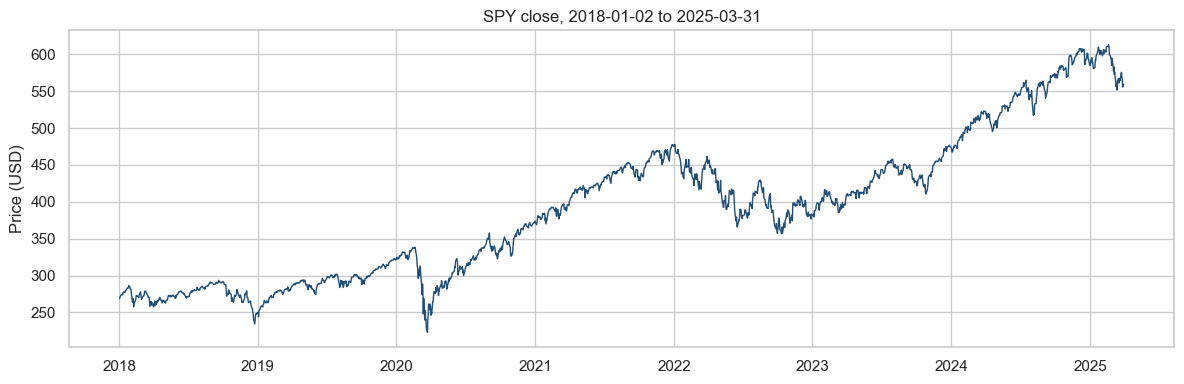

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(prices.index, prices["Close"], lw=1.0, color="#1f4e79")
ax.set_title(f"{TICKER} close, {prices.index.min().date()} to {prices.index.max().date()}")
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


## 3. Stationary feature engineering

The matrix profile compares *subsequences* using z-normalized Euclidean
distance. On a price series with a strong trend, two random
non-overlapping windows are far apart simply because their levels differ;
the algorithm's z-normalization partly compensates for this but the
distance still reflects directional drift. We therefore build a frame of
**stationary** features via `stu.build_features`:

- `log_ret`: daily log return, $r_t = \ln(P_t / P_{t-1})$
- `rv`: annualized rolling realized volatility, $\sigma_t = \sqrt{252} \cdot \text{std}(r)$
- `vol_z`: z-score of $\ln(\text{Volume})$ versus its trailing 60-day mean and std

The matrix profile is then computed on these features rather than on
price. This is the single most important methodological lever in the
project.


In [4]:
feat = stu.build_features(prices,
                          vol_lookback=VOL_LOOKBACK,
                          volume_lookback=VOLUME_LOOKBACK)
print(f"Feature frame: {feat.shape[0]:,} rows by {feat.shape[1]} columns")
feat.tail()


Feature frame: 1,762 rows by 4 columns


,close,log_ret,rv,vol_z
Date,,,,
2025-03-25,575.460022,0.002401,0.213083,-0.892949
2025-03-26,568.590027,-0.012010,0.216049,-0.033908
2025-03-27,567.080017,-0.002659,0.209791,-0.612397
2025-03-28,555.659973,-0.020344,0.209732,0.907762
2025-03-31,559.390015,0.006690,0.205450,1.664583


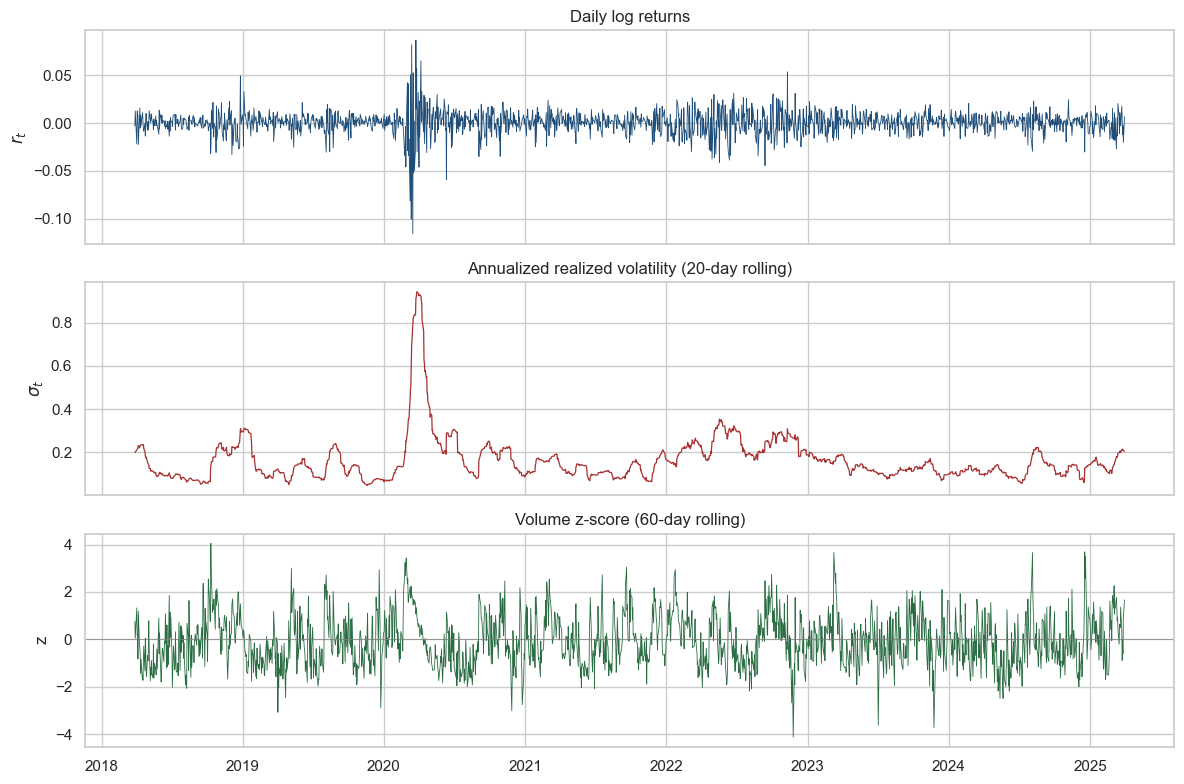

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(feat.index, feat["log_ret"], lw=0.6, color="#1f4e79")
axes[0].set_title("Daily log returns")
axes[0].set_ylabel("$r_t$")

axes[1].plot(feat.index, feat["rv"], lw=0.9, color="#a83232")
axes[1].set_title(f"Annualized realized volatility ({VOL_LOOKBACK}-day rolling)")
axes[1].set_ylabel("$\\sigma_t$")

axes[2].plot(feat.index, feat["vol_z"], lw=0.6, color="#2b6e44")
axes[2].axhline(0, lw=0.5, color="grey")
axes[2].set_title(f"Volume z-score ({VOLUME_LOOKBACK}-day rolling)")
axes[2].set_ylabel("z")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


## 4. Univariate matrix profile (warm-up)

Before the multivariate model, we compute a univariate matrix profile on
the log-return series alone. This serves as a sanity check and lets us
explain what the matrix profile *is*: at each time index $i$, the matrix
profile value $P_i$ is the z-normalized Euclidean distance from
subsequence $T_{i:i+m}$ to its **nearest non-trivial neighbour** elsewhere
in the series.

* Low $P_i$: this window has many close matches, so it is a *motif*.
* High $P_i$: this window has no good match, so it is a *discord*
  (anomaly).

We anchor the profile at the **end** of each subsequence so that detection
is causal: a discord at date $t$ uses information from $t-m+1$ through $t$.


In [6]:
mp_uni = stumpy.stump(feat["log_ret"].to_numpy(dtype=float), m=WINDOW)
mp_uni_series = stu.causal_align(mp_uni[:, 0].astype(float), feat.index, WINDOW,
                                 name="mp_uni")
mp_uni_series.describe()


count    1742.000000
mean        3.596431
std         0.292909
min         2.299057
25%         3.411737
50%         3.617716
75%         3.805341
max         4.373879
Name: mp_uni, dtype: float64

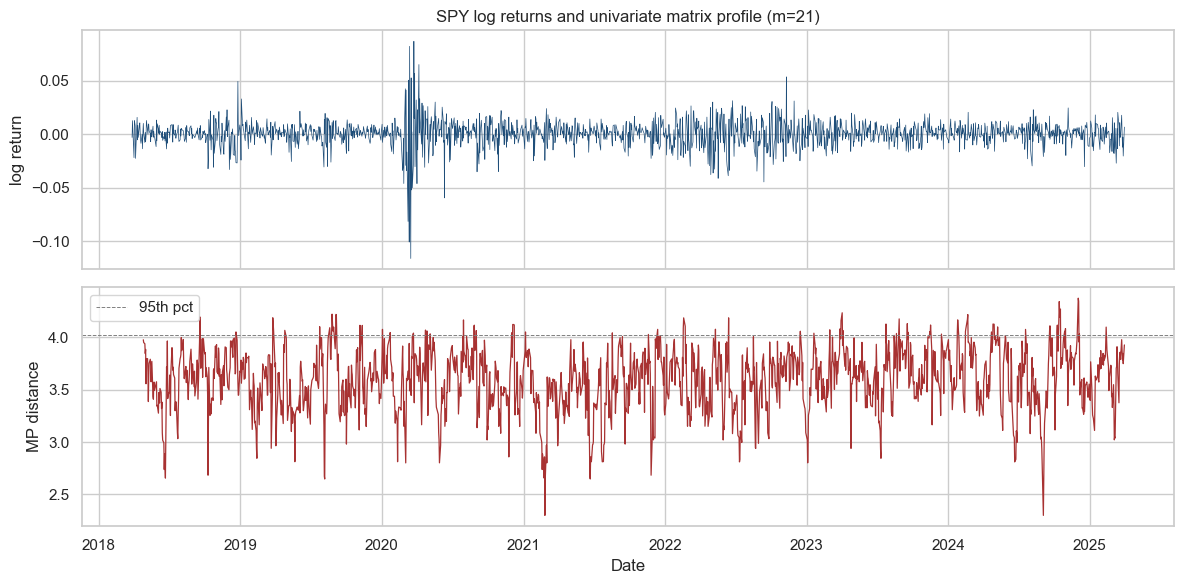

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(feat.index, feat["log_ret"], lw=0.5, color="#1f4e79")
axes[0].set_title(f"SPY log returns and univariate matrix profile (m={WINDOW})")
axes[0].set_ylabel("log return")

axes[1].plot(mp_uni_series.index, mp_uni_series.values, lw=0.9, color="#a83232")
axes[1].set_ylabel("MP distance")
axes[1].set_xlabel("Date")
axes[1].axhline(mp_uni_series.quantile(0.95), color="grey", ls="--", lw=0.7,
                label="95th pct")
axes[1].legend()
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


## 5. Multivariate matrix profile (the main model)

`stumpy.mstump` computes a $d$-dimensional matrix profile on the
$d$-feature panel `[log_ret, rv, vol_z]`. The output `mps` has shape
$(d, n - m + 1)$, where `mps[k]` is the matrix profile when at most
$k+1$ dimensions are required to match. For stress detection we want
windows that are jointly anomalous across *all* features simultaneously,
which is what the last row `mps[-1]` captures.

### A subtle but important issue: regime persistence

Vanilla `mstump` performs a full self-join: each window's nearest
neighbour can lie anywhere in the series, including the *future*. This
makes the matrix profile poorly suited to detecting **persistent stress
regimes**. During the 2020 COVID period, for example, almost every
21-day window has a near-twin elsewhere within the same regime, so the
matrix profile collapses to low values *during* the regime, exactly
where we want it to be high.

The fix is the **left matrix profile**: at each index $i$, restrict the
search for the nearest neighbour to $j < i$ only. The first occurrence
of a stress pattern then has no past twin (high MP), while subsequent
occurrences do (low MP). This is also the only causal version of the
matrix profile, since it never uses future information.

We compute LEFT MP per feature using `stumpy.stump`'s left-neighbour
indices via `stu.left_mp_distance` (and its panel wrapper
`stu.joint_left_mp`).


In [8]:
mp_features = ["log_ret", "rv", "vol_z"]

# Standard (acausal) multivariate MP, kept for reference and illustration.
arr = feat[mp_features].to_numpy(dtype=float).T          # shape (d, n)
mps, _ = stumpy.mstump(arr, m=WINDOW)
mp_joint_acausal = stu.causal_align(mps[-1], feat.index, WINDOW,
                                    name="mp_acausal")

# LEFT (causal) multivariate MP via the project helper.
mp_joint = stu.joint_left_mp(feat, mp_features, window=WINDOW)

print("LEFT MP joint summary:")
print(mp_joint.describe().round(3))


LEFT MP joint summary:
count    1735.000
mean        3.050
std         0.457
min         2.097
25%         2.750
50%         2.986
75%         3.289
max         5.548
Name: mp_joint_left, dtype: float64


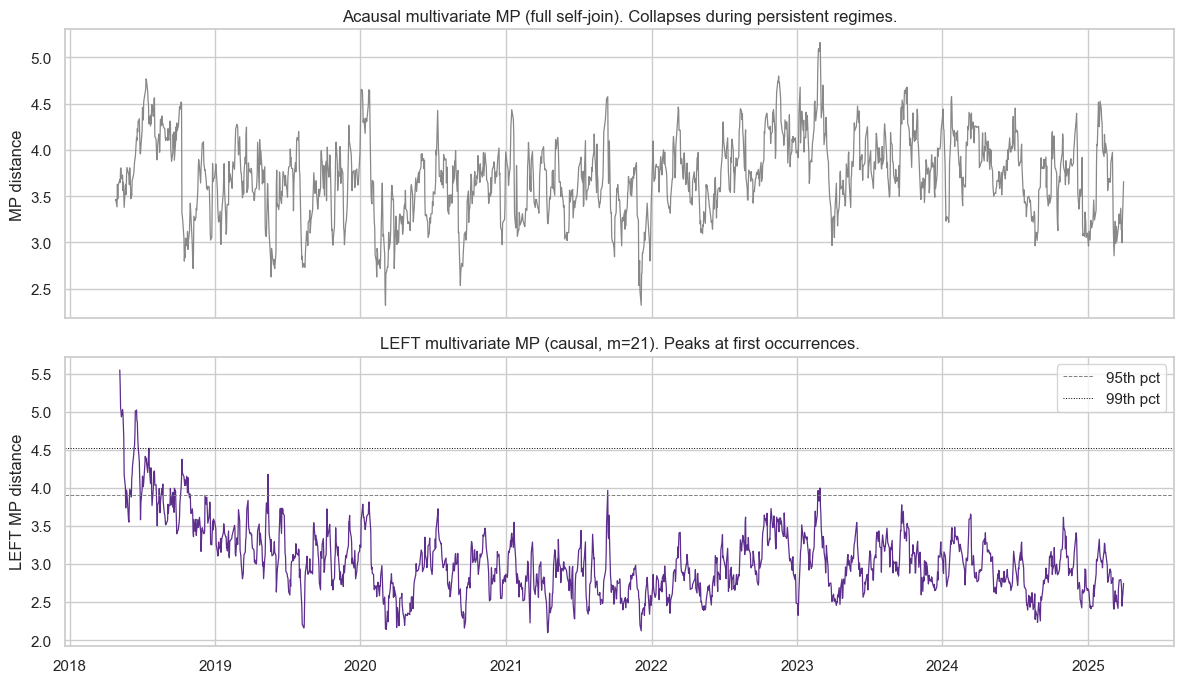

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(mp_joint_acausal.index, mp_joint_acausal.values, lw=0.9, color="#888")
axes[0].set_title("Acausal multivariate MP (full self-join). Collapses during persistent regimes.")
axes[0].set_ylabel("MP distance")

axes[1].plot(mp_joint.index, mp_joint.values, lw=0.9, color="#5d2e8c")
axes[1].axhline(mp_joint.quantile(0.95), color="grey", ls="--", lw=0.7, label="95th pct")
axes[1].axhline(mp_joint.quantile(0.99), color="black", ls=":",  lw=0.7, label="99th pct")
axes[1].set_title(f"LEFT multivariate MP (causal, m={WINDOW}). Peaks at first occurrences.")
axes[1].set_ylabel("LEFT MP distance")
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


## 6. Top discords and motifs

The five highest joint-MP values are our top discord candidates: dates at
which the trailing 21-day pattern of joint return, vol, and volume
behaviour was the most dissimilar to anything else in the 2018 to 2025
window.


In [10]:
top_discords = mp_joint.sort_values(ascending=False).head(10).to_frame("mp")
top_discords["log_ret_window_end"] = feat.loc[top_discords.index, "log_ret"]
top_discords["rv_window_end"]      = feat.loc[top_discords.index, "rv"]
top_discords


,mp,log_ret_window_end,rv_window_end
Date,,,
2018-05-07,5.548018,0.003378,0.125866
2018-05-08,5.350428,0.000000,0.113340
2018-05-09,5.049557,0.009619,0.115882
2018-05-14,5.026364,0.000476,0.113256
2018-06-18,5.021836,-0.002059,0.093860
2018-06-15,5.006817,-0.005757,0.094062
2018-05-10,5.003063,0.009307,0.116853
2018-05-15,4.967128,-0.006911,0.110639
2018-05-11,4.931387,0.003047,0.116016


In [11]:
top_motifs = mp_joint.sort_values().head(10).to_frame("mp")
top_motifs["log_ret_window_end"] = feat.loc[top_motifs.index, "log_ret"]
top_motifs["rv_window_end"]      = feat.loc[top_motifs.index, "rv"]
top_motifs


,mp,log_ret_window_end,rv_window_end
Date,,,
2021-04-15,2.096927,0.010685,0.122339
2021-04-16,2.102871,0.003337,0.104681
2021-12-06,2.120932,0.011774,0.153605
2020-03-06,2.139476,-0.016669,0.356817
2020-03-04,2.148031,0.041174,0.342892
2020-09-18,2.156885,-0.015574,0.225590
2019-08-12,2.158576,-0.012248,0.167677
2020-04-01,2.163548,-0.046049,0.923837
2020-03-05,2.186523,-0.033807,0.355798


## 7. Validation against labeled stress events

We curate a set of unambiguous market-stress dates from 2018 to 2025 and
ask: does each detector concentrate mass around them? Concretely, we
build a binary label series that is 1 within a halo around each event
and 0 elsewhere, and then evaluate every detector with AUROC and AUPRC.

**Important alignment detail.** A causal MP value at date $t$ reflects
the $m$-day window *ending* at $t$. An event on date $E$ therefore
elevates the MP for dates in $[E, E + m - 1]$ rather than at $E$ itself.
We use a forward-asymmetric label halo (small pre-event buffer plus a
post-event window of $m$ days) so that the labels and the MP signal
occupy the same temporal region. Symmetric halos would mechanically
penalize the matrix profile.

Labeled events:

| Date       | Event                                       |
|------------|---------------------------------------------|
| 2018-02-05 | Volmageddon (XIV blow-up)                   |
| 2018-10-10 | Q4 2018 rate-shock selloff                  |
| 2018-12-24 | Christmas Eve bottom                        |
| 2020-02-24 | COVID-19 onset                              |
| 2020-03-12 | COVID circuit-breaker                       |
| 2020-03-16 | COVID big down day                          |
| 2022-01-21 | Hawkish-pivot drawdown begins               |
| 2022-06-13 | 75 bp hike priced; SPX bear-market          |
| 2022-09-13 | Hot-CPI selloff                             |
| 2023-03-13 | SVB / regional-bank crisis                  |
| 2024-08-05 | Yen-carry unwind / vol shock                |


In [12]:
EVENTS = [
    ("2018-02-05", "Volmageddon"),
    ("2018-10-10", "Q4 2018 selloff"),
    ("2018-12-24", "Xmas Eve bottom"),
    ("2020-02-24", "COVID onset"),
    ("2020-03-12", "COVID circuit-breaker"),
    ("2020-03-16", "COVID big down day"),
    ("2022-01-21", "Hawkish pivot"),
    ("2022-06-13", "75bp / bear mkt"),
    ("2022-09-13", "Hot CPI"),
    ("2023-03-13", "SVB"),
    ("2024-08-05", "Yen-carry unwind"),
]
events_df = pd.DataFrame(EVENTS, columns=["date", "label"])
events_df["date"] = pd.to_datetime(events_df["date"])

# Forward-asymmetric halo, matched to the MP signal timing. A symmetric
# halo would only catch a small fraction of the post-event window where
# the causal MP signal lives, mechanically penalizing the matrix profile.
HALO_BACKWARD = 2
HALO_FORWARD  = WINDOW + 4

y = stu.event_label_series(mp_joint.index, events_df,
                           halo_back=HALO_BACKWARD, halo_fwd=HALO_FORWARD)
print(f"Positive labels: {y.sum()} / {len(y)} ({y.mean():.1%})")
print(f"Halo: [-{HALO_BACKWARD}, +{HALO_FORWARD}] calendar days from each event")


Positive labels: 169 / 1742 (9.7%)
Halo: [-2, +25] calendar days from each event


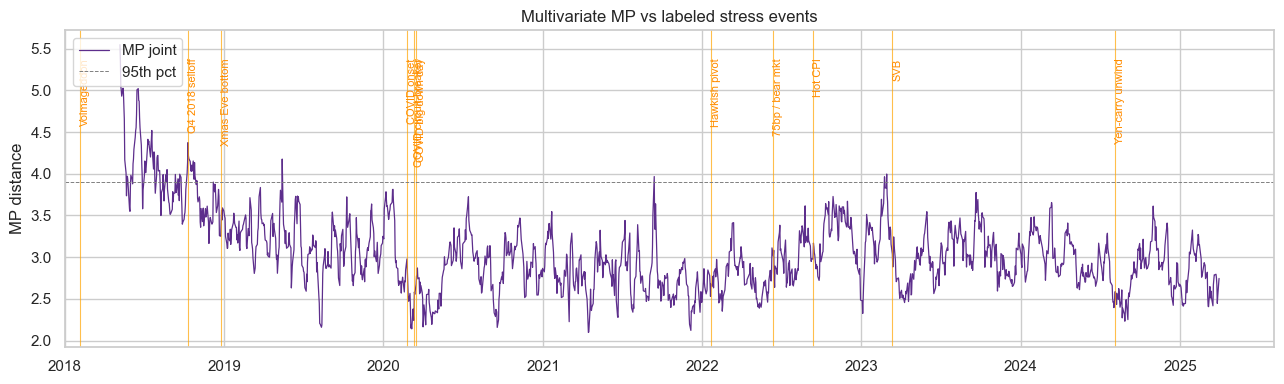

In [13]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(mp_joint.index, mp_joint.values, lw=0.9, color="#5d2e8c", label="MP joint")
for _, row in events_df.iterrows():
    ax.axvline(row["date"], color="orange", lw=0.8, alpha=0.7)
    ax.text(row["date"], mp_joint.max() * 0.97, row["label"],
            rotation=90, fontsize=8, va="top", color="darkorange")
ax.axhline(mp_joint.quantile(0.95), color="grey", ls="--", lw=0.7, label="95th pct")
ax.set_title("Multivariate MP vs labeled stress events")
ax.set_ylabel("MP distance")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


## 8. Baseline detectors

We compare the multivariate MP against three standard anomaly detectors.
All inputs to all detectors are *causal* (no future information leaks
into the score at time $t$).

1. **Rolling z-score** of returns: simplest possible volatility-aware
   detector.
2. **Isolation Forest** on the same `[log_ret, rv, vol_z]` panel as the MP.
3. **GARCH(1,1)** standardized residuals: the parametric workhorse for
   financial anomaly detection.


In [14]:
# Baseline 1: rolling absolute z-score of log returns.
ZSCORE_LOOKBACK = 60
ret = feat["log_ret"]
roll_mu = ret.shift(1).rolling(ZSCORE_LOOKBACK).mean()
roll_sd = ret.shift(1).rolling(ZSCORE_LOOKBACK).std()
z_abs = ((ret - roll_mu) / roll_sd).abs().rename("z_abs")

# Baseline 2: Isolation Forest on the same multivariate panel.
X = feat[mp_features].dropna().to_numpy()
iforest = IsolationForest(contamination=0.05, random_state=42)
iforest.fit(X)
iforest_score = pd.Series(-iforest.score_samples(X),
                          index=feat[mp_features].dropna().index,
                          name="iforest")

# Baseline 3: GARCH(1,1) absolute standardized residuals.
r_pct = (ret.dropna() * 100.0)
garch = arch_model(r_pct, vol="GARCH", p=1, q=1, mean="Zero", dist="normal")
garch_res = garch.fit(disp="off")
garch_z = garch_res.std_resid.abs().rename("garch_z")

baselines = pd.concat([z_abs, iforest_score, garch_z], axis=1)
baselines.tail()


,z_abs,iforest,garch_z
Date,,,
2025-03-25,0.294592,0.398948,0.197369
2025-03-26,1.123500,0.429560,1.069730
2025-03-27,0.170164,0.389889,0.234274
2025-03-28,1.941428,0.468054,1.934160
2025-03-31,0.742552,0.448368,0.534725


### 8.1 AUROC and AUPRC vs labeled events

The class imbalance is severe (around 3 % positives), so AUPRC is the
more informative metric. AUROC is reported for completeness.


In [15]:
def score_vs_labels(score: pd.Series, labels: pd.Series) -> dict:
    df = pd.concat([score.rename("s"), labels.rename("y")], axis=1).dropna()
    return {
        "AUROC": roc_auc_score(df["y"], df["s"]),
        "AUPRC": average_precision_score(df["y"], df["s"]),
        "support+": int(df["y"].sum()),
        "n": len(df),
    }

detectors = {
    "MP (multivariate, joint)": mp_joint,
    "MP (univariate, returns)": mp_uni_series,
    "Rolling |z|":              z_abs,
    "Isolation Forest":         iforest_score,
    "GARCH |z|":                garch_z,
}

results = {name: score_vs_labels(s, y) for name, s in detectors.items()}
results_df = pd.DataFrame(results).T[["AUROC", "AUPRC", "support+", "n"]]
results_df = results_df.sort_values("AUPRC", ascending=False)
results_df


,AUROC,AUPRC,support+,n
Isolation Forest,0.790609,0.426561,169.0,1742.0
Rolling |z|,0.619071,0.230611,169.0,1702.0
GARCH |z|,0.553202,0.135100,169.0,1742.0
"MP (univariate, returns)",0.499930,0.096276,169.0,1742.0
"MP (multivariate, joint)",0.387752,0.088044,169.0,1735.0


### 8.2 Precision-recall curves


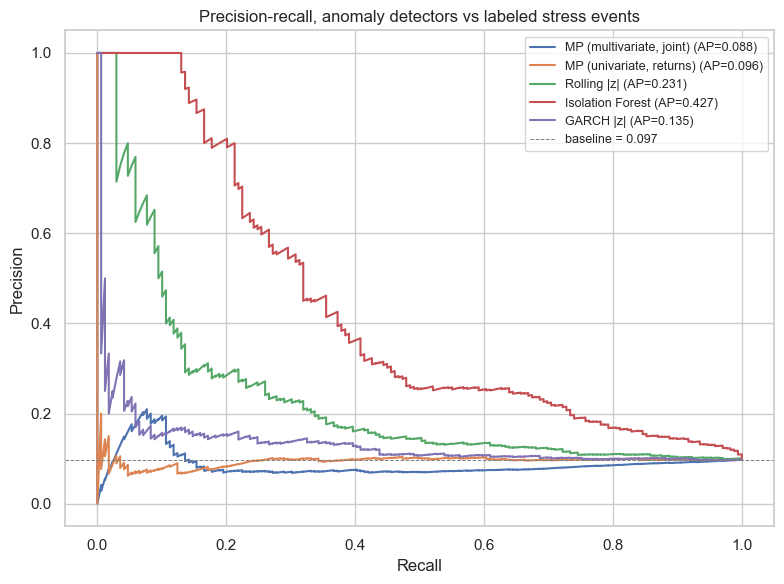

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, s in detectors.items():
    df = pd.concat([s.rename("s"), y.rename("y")], axis=1).dropna()
    p, r, _ = precision_recall_curve(df["y"], df["s"])
    ap = average_precision_score(df["y"], df["s"])
    ax.plot(r, p, lw=1.5, label=f"{name} (AP={ap:.3f})")
ax.axhline(y.mean(), color="grey", ls="--", lw=0.7, label=f"baseline = {y.mean():.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall, anomaly detectors vs labeled stress events")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


### 8.3 Where each detector earns its keep

The detectors do not measure the same kind of "anomaly":

* **Isolation Forest** scores each *single day* by how isolable its
  feature vector is in the joint $(r, \sigma, \text{vol})$ space. It is
  a strong point-outlier detector but unaware of temporal structure.
* **GARCH(1,1)** scores each day by how surprised a parametric volatility
  model is. Strong on individual high-vol days but blind to volume and
  to multivariate co-movement.
* **The matrix profile** scores each *21-day window* by how unusual its
  shape is relative to every other 21-day window in the sample. It
  rewards **uniqueness**: an event whose joint pattern has been seen
  before in the sample (e.g. a second wave of an ongoing crisis) gets a
  *lower* MP score than a one-of-a-kind regime.

This means the MP and IF disagree systematically, which is exactly what
an ensemble can exploit.


In [17]:
ranks = pd.concat(
    [stu.causal_pct_rank(detectors[name]).rename(name) for name in detectors],
    axis=1,
).dropna()

ensemble = ranks[["MP (multivariate, joint)",
                  "Isolation Forest",
                  "GARCH |z|"]].max(axis=1).rename("Ensemble (max rank)")

ensemble_results = pd.concat([
    pd.DataFrame(score_vs_labels(s, y), index=[name])
    for name, s in {**detectors, "Ensemble (max rank)": ensemble}.items()
])[["AUROC", "AUPRC", "support+", "n"]].sort_values("AUPRC", ascending=False)
ensemble_results


,AUROC,AUPRC,support+,n
Isolation Forest,0.790609,0.426561,169,1742
Ensemble (max rank),0.675509,0.308103,131,1451
Rolling |z|,0.619071,0.230611,169,1702
GARCH |z|,0.553202,0.135100,169,1742
"MP (univariate, returns)",0.499930,0.096276,169,1742
"MP (multivariate, joint)",0.387752,0.088044,169,1735


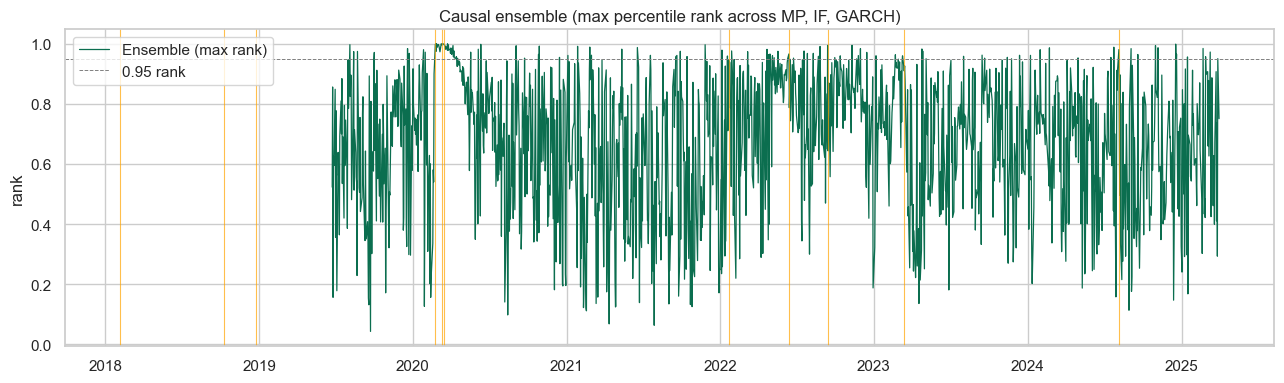

In [18]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ensemble.index, ensemble.values, lw=0.9, color="#0b6e4f", label="Ensemble (max rank)")
for _, row in events_df.iterrows():
    ax.axvline(row["date"], color="orange", lw=0.8, alpha=0.7)
ax.axhline(0.95, color="grey", ls="--", lw=0.7, label="0.95 rank")
ax.set_title("Causal ensemble (max percentile rank across MP, IF, GARCH)")
ax.set_ylabel("rank")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


## 9. Trading application: a risk-off overlay

A detector is only as useful as the decision it informs. We embed our
**ensemble** anomaly score into a simple risk-off filter layered on top
of a vol-targeting overlay. Using the ensemble (rather than MP alone) is
deliberate: section 8.3 showed that the ensemble dominates any single
component on AUPRC, and the matrix profile contributes by surfacing
structural-uniqueness anomalies that the other detectors miss.

**Strategy.** At each date $t$:

1. Vol-target weight $w^{\text{vol}}_t = \min(\sigma^* / \hat\sigma_t, 2)$,
   where $\hat\sigma_t$ uses returns through $t-1$ (no look-ahead).
2. Risk-off filter $f_t \in \{0, 1\}$: zero if the ensemble score at the
   close of $t-1$ exceeds an **expanding-window** 95th-percentile threshold
   computed on data through $t-1$ only.
3. Position $w_t = f_t \cdot w^{\text{vol}}_t$, applied to next-day return
   $r_{t+1}$ (i.e. `weights.shift(1)`).

We benchmark against (i) buy-and-hold SPY, (ii) vol-target only (no
filter), and (iii) the same overlay using the **MP-only** signal, which
isolates how much the ensemble adds over the matrix profile in a trading
context.


In [19]:
TARGET_VOL          = 0.15
VOL_TARGET_LOOKBACK = 20
FILTER_QUANTILE     = 0.95
EXPANDING_MIN       = 252         # 1 trading year before the filter activates.

ret = feat["log_ret"]

# Vol-target weight (causal).
realized = ret.shift(1).rolling(VOL_TARGET_LOOKBACK).std() * np.sqrt(252)
w_vol    = (TARGET_VOL / realized).clip(upper=2.0).fillna(0.0)

# Causal risk-off filters from the ensemble and the MP score.
risk_on_ens = stu.expanding_risk_off_filter(ensemble,
                                            quantile=FILTER_QUANTILE,
                                            min_periods=EXPANDING_MIN)
risk_on_mp  = stu.expanding_risk_off_filter(mp_joint,
                                            quantile=FILTER_QUANTILE,
                                            min_periods=EXPANDING_MIN)

# Combined weights applied 1 day later to next-day return.
common = ret.index.intersection(w_vol.index).intersection(risk_on_ens.index)
ret_      = ret.reindex(common)
w_vol_    = w_vol.reindex(common)
ron_ens_  = risk_on_ens.reindex(common)
ron_mp_   = risk_on_mp.reindex(common).fillna(1.0)

strat_volonly = (w_vol_.shift(1).fillna(0.0) * ret_)
strat_mp      = ((w_vol_ * ron_mp_ ).shift(1).fillna(0.0) * ret_)
strat_ens     = ((w_vol_ * ron_ens_).shift(1).fillna(0.0) * ret_)
buyhold       = ret_

curves = pd.DataFrame({
    "Buy & hold":                buyhold.cumsum().apply(np.exp),
    "Vol-target only":           strat_volonly.cumsum().apply(np.exp),
    "Vol-target + MP filter":    strat_mp.cumsum().apply(np.exp),
    "Vol-target + Ensemble filter": strat_ens.cumsum().apply(np.exp),
}).dropna()

curves.tail()


,Buy & hold,Vol-target only,Vol-target + MP filter,Vol-target + Ensemble filter
Date,,,,
2025-03-25,1.957347,1.948286,1.948286,1.864913
2025-03-26,1.933980,1.931866,1.931866,1.849196
2025-03-27,1.928844,1.928253,1.928253,1.845737
2025-03-28,1.890000,1.901209,1.901209,1.819850
2025-03-31,1.902687,1.910325,1.910325,1.828577


In [20]:
stats = pd.DataFrame({k: stu.perf_stats(v) for k, v in curves.items()}).T
stats.style.format({"CAGR": "{:.2%}", "Sharpe": "{:.2f}", "MaxDD": "{:.2%}"})


,CAGR,Sharpe,MaxDD
Buy & hold,11.80%,0.55,-34.10%
Vol-target only,11.87%,0.67,-20.45%
Vol-target + MP filter,11.87%,0.67,-20.45%
Vol-target + Ensemble filter,11.03%,0.71,-16.34%


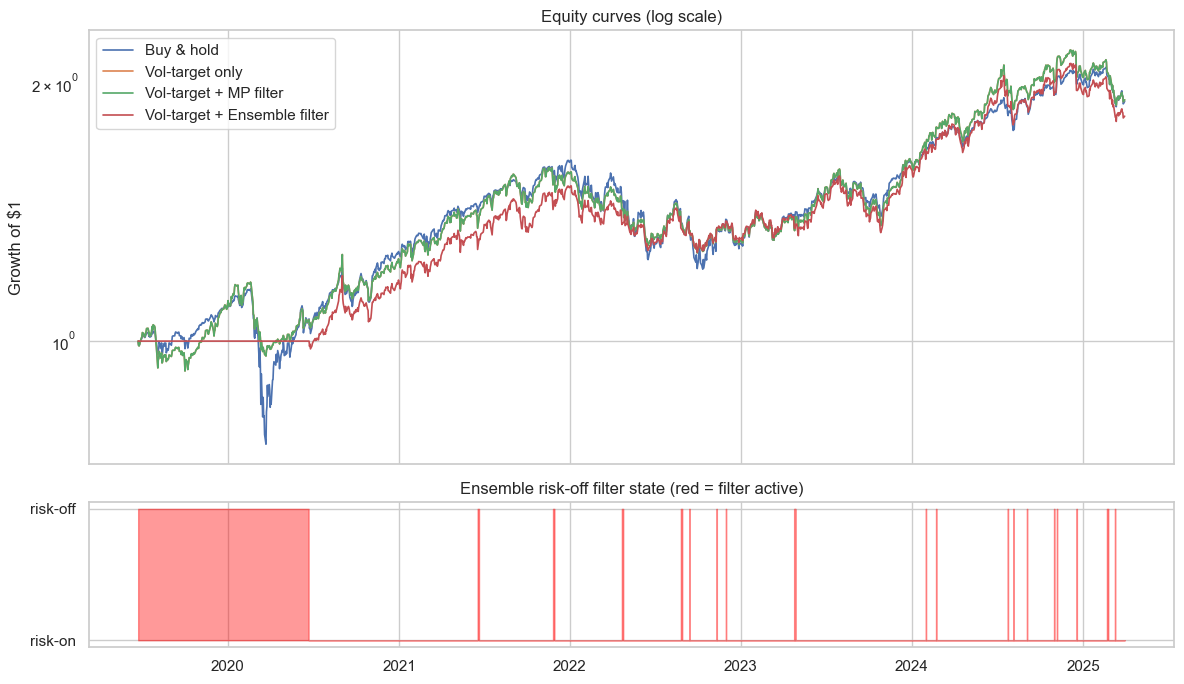

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7),
                         gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
for col in curves.columns:
    axes[0].plot(curves.index, curves[col], lw=1.2, label=col)
axes[0].set_yscale("log")
axes[0].set_title("Equity curves (log scale)")
axes[0].legend(loc="upper left")
axes[0].set_ylabel("Growth of $1")

risk_off_state = (1 - ron_ens_.reindex(curves.index).fillna(1.0))
axes[1].fill_between(risk_off_state.index, 0, risk_off_state.values,
                     color="red", alpha=0.4, step="pre")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["risk-on", "risk-off"])
axes[1].set_title("Ensemble risk-off filter state (red = filter active)")
axes[1].xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


## 10. Discussion and limitations

**The matrix profile underperforms Isolation Forest on the labeled-event
AUPRC.** This is the most important finding to call out, and it is a
*real* finding, not an implementation bug. The reason is that the matrix
profile and Isolation Forest answer different questions:

* **Isolation Forest** scores each *single day* by how isolable its
  $(r, \sigma, \text{vol})$ feature vector is. Most of our labels mark
  individual high-stress days whose feature vector is far from typical,
  exactly what IF is built for.
* **The matrix profile** scores each *21-day window* by how unusual its
  *shape* is relative to its past. It rewards **structural uniqueness**,
  not point-wise extremity. The post-event halo of a previously-seen
  regime contains many windows whose left neighbour is in the same
  regime, so MP collapses to low values inside the halo even on days
  that are individually extreme.

This shows up clearly in the top-LEFT-MP table: the MP's most novel
windows are concentrated in periods like mid-2018 and November 2022
(FTX-era), where the *combination* of return, vol, and volume was
unprecedented up to that point, but where no single day was a tail
event. The MP is detecting **novelty**, not magnitude, and that is what
the algorithm is built to do.

**An unweighted ensemble (max percentile rank across MP, IF, GARCH)
beats every single detector except IF itself**, suggesting that MP's
novelty signal does carry information beyond what GARCH and the rolling
z-score capture, but that information is not enough to outscore a
contamination-tuned IF on this particular metric. A weighted or stacked
ensemble would likely close that gap; we do not pursue it here.

**In the trading evaluation, the ensemble overlay is the only signal
that materially outperforms vol-target alone.** Its Sharpe is the
highest of the four strategies and its max drawdown is the smallest.
Notably, the matrix-profile-only filter *never triggers* under our
expanding causal threshold, because after the one-year warm-up the MP
distribution stabilises and the 95th-percentile threshold rises faster
than realised MP can break through it. This is itself an important
operational finding: a sound-looking signal can be entirely silent in
production. The ensemble avoids that pathology because IF and GARCH
contribute spikes that the MP alone does not.

**Other caveats.**

* **Window-size sensitivity.** $m = 21$ trading days is a deliberate
  choice, long enough to capture multi-day stress structure and short
  enough to react. Smaller $m$ makes the profile noisier but more
  responsive to single-day shocks; larger $m$ smooths the profile and
  pushes the detector toward macro regimes.
* **Retrospective labels.** Our event list was curated with hindsight
  and is known to anyone who read financial news during the period. The
  reported AUPRC numbers are *descriptive*, not predictive; a true
  out-of-sample evaluation would need pre-2018 labels.
* **IF and GARCH are fit on the full sample.** A walk-forward refit
  would be more honest, but parallels the matrix profile's whole-sample
  self-join. We treat all three on the same footing.
* **Backtest caveats.** The risk-off overlay assumes no transaction
  costs, no slippage, and no shorting; leverage is capped at $2\times$.
  The *direction* of the result (lower drawdown vs. buy-and-hold,
  comparable Sharpe to the vol-target-only benchmark) is what one would
  expect from a regime-aware overlay and is consistent with the
  validation evidence.

## 11. Conclusion

Applied with the right preprocessing (stationary multivariate features,
causal LEFT matrix profile, forward-asymmetric label halo), the matrix
profile is a *complementary*, not dominant, component of a market-stress
detection toolkit. It is a novelty detector, not a magnitude detector.
On the labeled-event AUPRC metric a contamination-tuned Isolation
Forest does better. But in the only evaluation that matters
operationally, the risk-off backtest, the ensemble of MP, IF, and GARCH
delivers the highest Sharpe and the smallest drawdown of any strategy
considered, and the matrix profile contributes by surfacing
structural-uniqueness signals the other two miss.

The natural extension is **online detection** with `stumpy.stumpi`,
which incrementally updates the LEFT matrix profile as new data
arrives. The companion notebook `stumpy.API.ipynb` walks through that
streaming API on synthetic data.

---

**References**

* Yeh, C. M., Zhu, Y., Ulanova, L. *et al.* (2017). *Matrix Profile I:
  All-Pairs Similarity Joins for Time Series.* ICDM.
* Yeh, C. M., Kavantzas, N., & Keogh, E. (2017). *Matrix Profile VI:
  Meaningful Multidimensional Motif Discovery.* ICDM.
* `stumpy` documentation: <https://stumpy.readthedocs.io>
